In [95]:
import pandas as pd
import numpy as np
import sys
import warnings
import itertools
warnings.filterwarnings("ignore")
from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_acf
from matplotlib import pyplot as plt
import statsmodels.api as sm
import statsmodels.tsa.api as smt
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
%matplotlib inline
import datetime
import calendar
import seaborn as sns
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima_model import ARMA, ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [97]:
data = pd.read_csv("champagn.csv")

In [99]:
data.head(3)

,Month,Sales
0,1964-01,2815
1,1964-02,2672
2,1964-03,2755


In [101]:
dates=pd.date_range(start='1964-01-01', freq='MS', periods=len(data))
dates[0:5]

DatetimeIndex(['1964-01-01', '1964-02-01', '1964-03-01', '1964-04-01',
               '1964-05-01'],
              dtype='datetime64[ns]', freq='MS')

In [103]:
data.set_index(dates, inplace=True)
data.drop("Month", axis=1, inplace=True)

In [105]:
data.head(3)

,Sales
1964-01-01,2815
1964-02-01,2672
1964-03-01,2755


# MODELING

In [108]:
train = (data[data.index < "1969-10-01"])
test =  (data[data.index >= "1969-10-01"])

# MODEL 1: AUT0 REgressive

### auto regressive model creates a lag data so that correlation of the created lag is high with the original data plot.
### by default the alogorithm shows the best lag

In [112]:
from statsmodels.tsa.ar_model import AutoReg


In [114]:
lags = 12
model = AutoReg(train,lags=lags)
model_fit = model.fit()

In [116]:
# assuming you have already fitted the model (as shown in the previous code snippet)

# Get the number of lags considered statistically
lags_statistically = lags

#Get the coefficents (beta values) of the model
coefficients = model_fit.params

# print the results
print(f"Lags considered statistically: {lags_statistically}")
print(f"coefficients (beta values):\n{coefficients}")

Lags considered statistically: 12
coefficients (beta values):
const        774.861360
Sales.L1       0.068774
Sales.L2      -0.106691
Sales.L3       0.104460
Sales.L4      -0.145569
Sales.L5       0.070221
Sales.L6      -0.099998
Sales.L7       0.091160
Sales.L8      -0.117216
Sales.L9       0.036002
Sales.L10     -0.087992
Sales.L11      0.170959
Sales.L12      0.940454
dtype: float64


In [118]:
# predecting the test values
predictions = model_fit.predict(start=len(train), end=len(train)+len(test)-1, dynamic=False)

In [120]:
print("The first test values is sales :" ,test.values[1],"and its predited value:", predictions.values[1])

The first test values is sales : [10803] and its predited value: 11124.162022696057


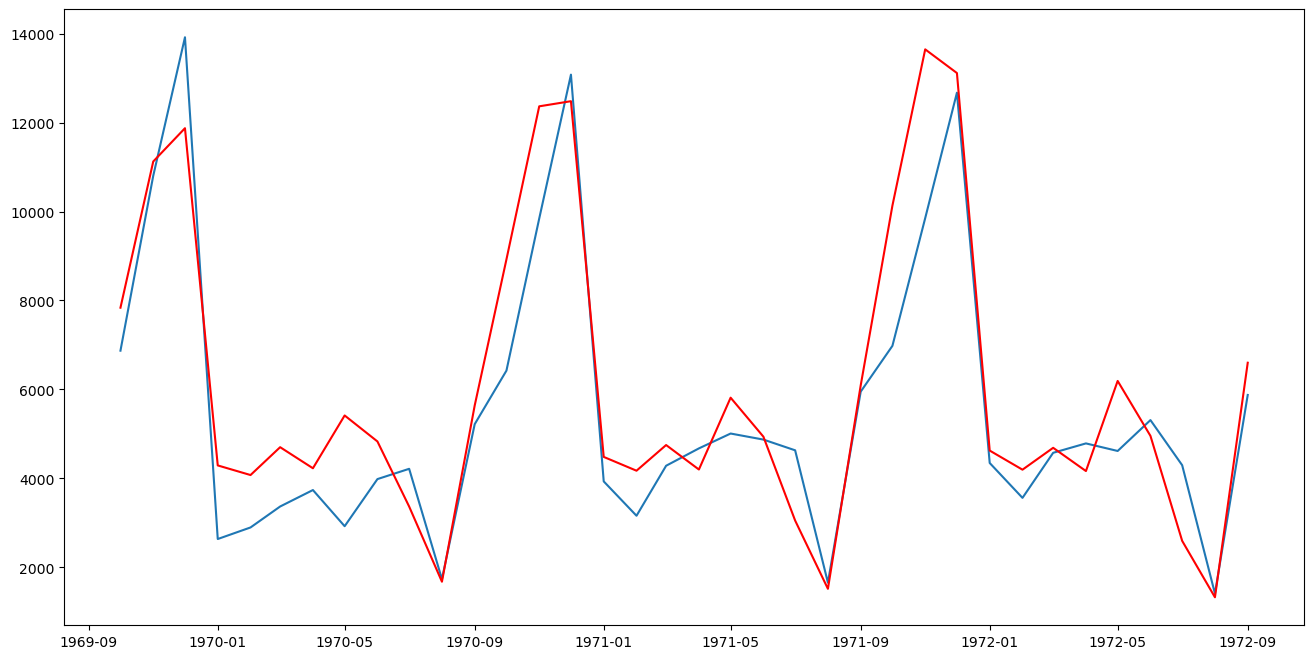

In [122]:
# plot results
plt.figure(figsize=(16,8))
plt.plot(test)
plt.plot(predictions, color="red")
plt.show()

In [124]:
# root mean square error(RMSE)
rmse = np.sqrt(mean_squared_error(test["Sales"], predictions))
rmse = round(rmse, 3)

In [126]:
#Mean Absplute Percentage Error
abs_error = np. abs(test[ 'Sales'] -predictions)
actual = test[ 'Sales']
mape = np. round (np. mean (abs_error/actual), 3)
resultsDf = pd. DataFrame({ 'Method': ['Auto Regressive'], 'RMSE': [rmse]})
resultsDf
mape

0.208

In [128]:
# Storing results in a dataframe
resultsDf = pd. DataFrame ({'Method': ['Auto Regressive'], 'MAPE': [mape], 'RMSE': [rmse]})
resultsDf = resultsDf[[ 'Method', 'RMSE', 'MAPE' ]]
resultsDf

,Method,RMSE,MAPE
0,Auto Regressive,1379.475,0.208


# MODEL2:

Best ARIMA (5, 0) model - AIC: 1232.6057290763674
Order of AR part: 5
Coefficients: const     4.373464e+03
ar.L1     6.364088e-01
ar.L2    -2.325099e-01
ar.L3     4.779038e-02
ar.L4    -2.634829e-01
ar.L5     2.701239e-01
sigma2    2.827232e+06
dtype: float64
Mean Squared Error: 10153584.05549386


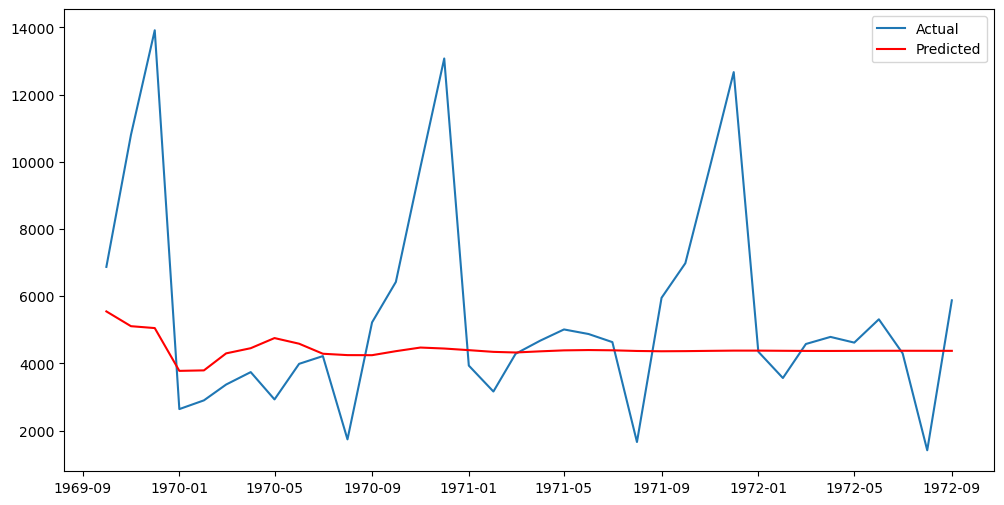

,Method,RMSE,MAPE
0,Auto Regressive,1379.475,0.208
0,Auto Regressive Moving Average,3186.469,0.383


In [131]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# Define the p and q parameters to take any value between 0 and 7
p = range(0, 7)
q = range(0, 1)

# Generate all different combinations of p, q
pq = list(itertools.product(p, q))
best_aic = np.inf
best_pq = None
temp_model = None

# Assume `train` and `test` are defined DataFrame/Series containing the training and testing data
# Example: train, test = data[:train_size], data[train_size:]

for param in pq:
    try:
        temp_model = ARIMA(train, order=(param[0], 0, param[1]))
        results = temp_model.fit()
        if results.aic < best_aic:
            best_aic = results.aic
            best_pq = param
    except:
        continue

print("Best ARIMA {} model - AIC: {}".format(best_pq, best_aic))

# Using the best parameter in the model
model = ARIMA(train, order=(best_pq[0], 0, best_pq[1]))
model_fit = model.fit()

# Print the order of the AR part of the model
print('Order of AR part: %s' % best_pq[0])

# Print the coefficients
print('Coefficients: %s' % model_fit.params)

# Predicting the test data
predictions = model_fit.predict(start=len(train), end=len(train) + len(test) - 1)

# Calculate mean squared error
mse = mean_squared_error(test, predictions)
print('Mean Squared Error:', mse)

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(test, label='Actual')
plt.plot(predictions, color='red', label='Predicted')
plt.legend()
plt.show()

# Root Mean Square Error (RMSE)
rmse = np.sqrt(mean_squared_error(test['Sales'], predictions))
rmse = round(rmse, 3)

# Mean Absolute Percentage Error (MAPE)
abs_error = np.abs(test['Sales'] - predictions)
actual = test['Sales']
mape = np.round(np.mean(abs_error / actual), 3)

# Storing results in a dataframe
tempResultsDf = pd.DataFrame({'Method': ['Auto Regressive Moving Average'], 'RMSE': [rmse], 'MAPE': [mape] })

# Assuming resultsDf is predefined and contains previous results
resultsDf = pd.concat([resultsDf, tempResultsDf])
resultsDf = resultsDf[['Method', 'RMSE', 'MAPE']]
resultsDf


# Model 2: Seasonal Auto Regressive Integrated Moving Average(ARMA)

It combines the ARIMA model with the ability to platform the same autoregression, differencing and moving average modeling at the seasonal level

Best SARIMA(0, 1, 1)x(1, 1, 1, 12) model - AIC: 666.1183090126067


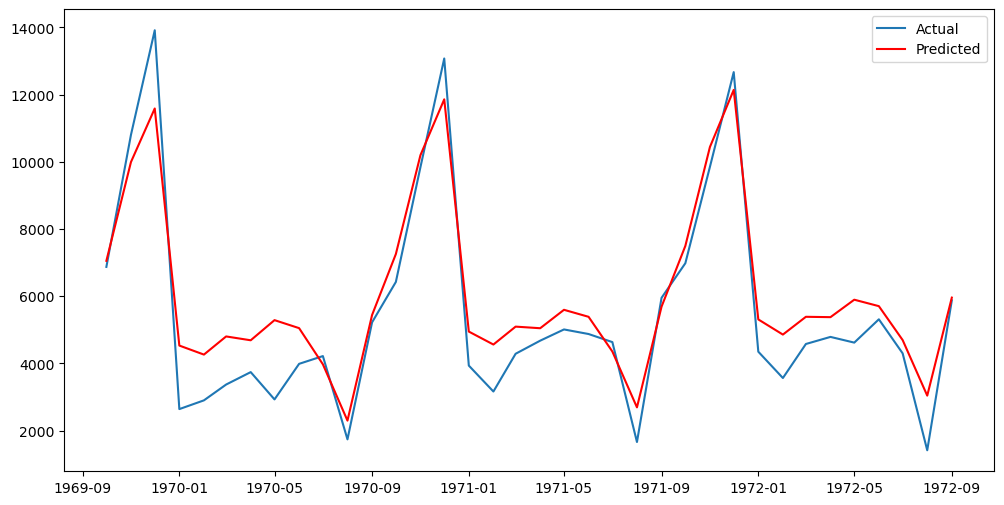

                                              Method      RMSE   MAPE
0                                    Auto Regressive  1379.475  0.208
1                     Auto Regressive Moving Average  3186.469  0.383
2  Seasonal Autoregressive Integrated Moving Average  1035.182  0.235


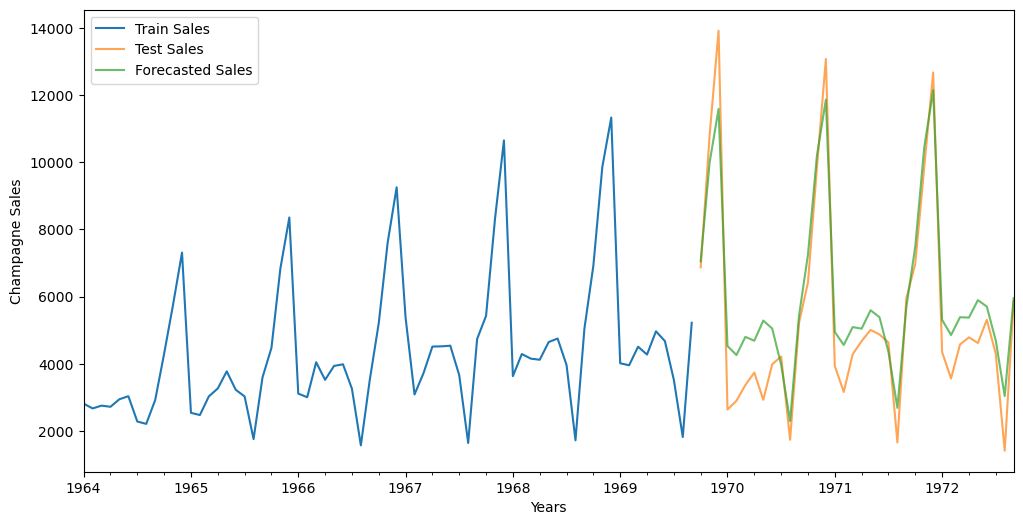

In [153]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

# Define the p, d, and q parameters to take any value between 0 and 2
p = d = q = range(0, 2)

# Generate all different combinations of p, d, and q triplets
pdq = list(itertools.product(p, d, q))

# Generate all different combinations of seasonal p, d, and q triplets
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in pdq]

best_aic = np.inf
best_pdq = None
best_seasonal_pdq = None
temp_model = None

# Assuming `train` is your training dataset
for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            temp_model = SARIMAX(train, order=param, seasonal_order=param_seasonal, enforce_invertibility=False, enforce_stationarity=False)
            results = temp_model.fit(disp=False)
            if results.aic < best_aic:
                best_aic = results.aic
                best_pdq = param
                best_seasonal_pdq = param_seasonal
        except:
            continue

print("Best SARIMA{}x{} model - AIC: {}".format(best_pdq, best_seasonal_pdq, best_aic))

# Using the best parameters in the model
model = SARIMAX(train, order=best_pdq, seasonal_order=best_seasonal_pdq, enforce_invertibility=False, enforce_stationarity=False)
model_fit = model.fit()

# Assuming `test` is your testing dataset
predictions = model_fit.predict(start=len(train), end=len(train) + len(test) - 1, dynamic=False)

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(test, label='Actual')
plt.plot(predictions, color='red', label='Predicted')
plt.legend()
plt.show()

# Root Mean Square Error (RMSE)
rmse = np.sqrt(mean_squared_error(test['Sales'], predictions))
rmse = round(rmse, 3)

# Mean Absolute Percentage Error (MAPE)
abs_error = np.abs(test['Sales'] - predictions)
actual = test['Sales']
mape = np.round(np.mean(abs_error / actual), 3)

# Storing results in a dataframe
tempResultsDf = pd.DataFrame({'Method': ['Seasonal Autoregressive Integrated Moving Average'], 'RMSE': [rmse], 'MAPE': [mape]})
resultsDf = pd.concat([resultsDf, tempResultsDf])
resultsDf = resultsDf[['Method', 'RMSE', 'MAPE']]
resultsDf.index = [i for i in range(len(resultsDf))]
print(resultsDf)

# Plotting the train, test, and forecasted sales
axis = train['Sales'].plot(label='Train Sales', figsize=(12, 6))
test['Sales'].plot(ax=axis, label='Test Sales', alpha=0.7)
predictions.plot(ax=axis, label='Forecasted Sales', alpha=0.7)
axis.set_xlabel('Years')
axis.set_ylabel('Champagne Sales')
plt.legend(loc='best')
plt.show() 
plt.close()
